In [1]:
import pandas as pd
import geopandas as gpd
import rioxarray
from shapely.geometry import  Point
import cv2
import matplotlib.pyplot as plt
from georefcam.camera_model import CTCameraModel
from georefcam.dem import RasterioDEM
from georefcam.georefcam import GeoRefCam, get_direction_vector
import numpy as np
import pyvista as pv
import rioxarray
from PIL import Image
import glob
import os
from tqdm import tqdm
from shapely.ops import unary_union
import json

from dem_utils import compute_dem_bbox_from_point, download_dem_eio, reproject_and_save_dem

In [2]:
import numpy as np

def check_camera_in_dem(cam_loc, dem_points):
    # Get DEM bounds
    x_min, x_max = dem_points[:, :, 0].min(), dem_points[:, :, 0].max()
    y_min, y_max = dem_points[:, :, 1].min(), dem_points[:, :, 1].max()
    z_min, z_max = dem_points[:, :, 2].min(), dem_points[:, :, 2].max()

    cam_x, cam_y, cam_z = cam_loc

    in_x = x_min <= cam_x <= x_max
    in_y = y_min <= cam_y <= y_max
    inside_dem = in_x and in_y

    # Distance to borders (always positive)
    dx_left = abs(cam_x - x_min)
    dx_right = abs(x_max - cam_x)
    dy_bottom = abs(cam_y - y_min)
    dy_top = abs(y_max - cam_y)

    print(f"📷 Camera location (XYZ): {cam_loc}")
    print(f"🗺️  DEM bounds: X ({x_min:.1f} to {x_max:.1f})")
    print(f"               Y ({y_min:.1f} to {y_max:.1f})")
    print(f"               Z ({z_min:.1f} to {z_max:.1f})")
    print(f"📌 Inside DEM (XY): {inside_dem}")
    print(f"↔️  Distance to X borders: left={dx_left:.1f} m, right={dx_right:.1f} m")
    print(f"↕️  Distance to Y borders: bottom={dy_bottom:.1f} m, top={dy_top:.1f} m")

    if not inside_dem:
        print("⚠️  WARNING: Camera is outside DEM bounds")

    return {
        "inside": inside_dem,
        "dx_left": dx_left,
        "dx_right": dx_right,
        "dy_bottom": dy_bottom,
        "dy_top": dy_top
    }


In [3]:
name = "haguenau"


# === Load Camera Metadata ===
with open(f"site_data/{name}/camera_config.json", "r") as f:
    loaded_config = json.load(f)

# Extract values
lat = loaded_config["lat"]
lon = loaded_config["lon"]

tilt = loaded_config["tilt"]
roll = loaded_config["roll"]
elevation = loaded_config["elevation"]
fov_x = loaded_config["fov_x"]
fov_y = loaded_config["fov_y"]
img_size = tuple(loaded_config["img_size"])

# Use name as login or define separately
cam_name = name

# === Camera Info as GeoDataFrame ===
cam_info = pd.Series({
    "login": cam_name,
    "lat": lat,
    "lon": lon,
    "geometry": Point(lon, lat),
    "azimuth": 0.0,
    "tilt": tilt,
    "elevation": elevation,
    "roll": roll,
})
gdf_cams = gpd.GeoDataFrame([cam_info], geometry="geometry", crs="EPSG:4326")

In [4]:
# bbox = compute_dem_bbox_from_point(lat, lon, buffer_km=30)
# download_dem_eio(bbox)
# reproject_and_save_dem("srtm_dem.tif", "srtm_dem_l93.tif")

In [5]:
# === Prepare DEM ===
dem_data = rioxarray.open_rasterio(f"site_data/{name}/dsm_min.tif", masked=True).squeeze()
if dem_data.rio.crs != "EPSG:2154":
    dem_data = dem_data.rio.reproject("EPSG:2154")
dem_path = "dem_l93.tif"
dem_data.rio.to_raster(dem_path)

dem = RasterioDEM(dem_path, crs="EPSG:2154")
dem.build_pcd(sample_step=2)
dem.build_mesh()

print("[DEBUG] Mesh bounds:", dem.mesh.bounds)
print("[DEBUG] Mesh extents (X/Y):", dem.mesh.extents[:2])
print("[DEBUG] Mesh centroid:", dem.mesh.centroid)

mesh.vertices.shape = (12257001, 3)
mesh.vertices[:5] = [[1.04699990e+06 6.87100032e+06 1.60460000e+02]
 [1.04700190e+06 6.87100032e+06 1.60370000e+02]
 [1.04700390e+06 6.87100032e+06 1.60400000e+02]
 [1.04700590e+06 6.87100032e+06 1.60420000e+02]
 [1.04700790e+06 6.87100032e+06 1.60400000e+02]]
[DEBUG] Mesh bounds: [[ 1.04699990e+06  6.86400032e+06 -9.99900000e+03]
 [ 1.05399990e+06  6.87100032e+06  1.96870000e+02]]
[DEBUG] Mesh extents (X/Y): [7000. 7000.]
[DEBUG] Mesh centroid: [ 1.05069130e+06  6.86718571e+06 -4.17079723e+03]


In [16]:
import numpy as np
from pyproj import CRS, Transformer
from georefcam.camera_model import CTCameraModel  # your actual class
import pandas as pd
from shapely.geometry import Point


azimuth = 42


cam_crs = CRS.from_user_input("EPSG:2154")


# === Step 1: Instantiate your camera model ===
cam_model = CTCameraModel(
    image_res   = img_size,
    fov_x_deg   = fov_x,
    fov_y_deg   = fov_y,
    azimuth_deg = azimuth,
    tilt_deg    = tilt,
    roll_deg    = cam_info.roll,
    lat         = cam_info.lat,
    lon         = cam_info.lon,
    elevation   = cam_info.elevation,
    crs         = cam_crs.to_string()
)

# === Step 2: Compute center pixel ray ===
w, h = cam_model.image_res
center_pixel = np.array([[w / 2, h / 2]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(center_pixel)

origin = rays[0, :, 0]
target = rays[0, :, 1]

# === Step 3: Reproject to WGS84 ===
lon_o, lat_o = cam_model.tf_local_to_wgs84.transform(origin[0], origin[1])
lon_t, lat_t = cam_model.tf_local_to_wgs84.transform(target[0], target[1])


# === Step 4: Compute WGS84 azimuth ===
def compute_azimuth(lat1, lon1, lat2, lon2):
    dlon = np.radians(lon2 - lon1)
    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    return (np.degrees(np.arctan2(y, x)) + 360) % 360

computed_az = compute_azimuth(lat_o, lon_o, lat_t, lon_t)

# === Final output ===
print(f"Expected azimuth: {azimuth:.2f}°")
print(f"Computed center ray azimuth (WGS84): {computed_az:.2f}°")


Expected azimuth: 42.00°
Computed center ray azimuth (WGS84): 42.00°


In [17]:
fov_x/4

13.5

In [18]:


# === Step 1: Compute camera location and direction ===
geocam = GeoRefCam(cam_model, dem)

cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)

# Reproject camera location if needed
if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(
        np.array([geocam.camera_model.cam_loc[:3]])
    )[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]
cam_loc

(1050735.6266334413, 6868633.518812106, 180)

In [19]:
cam_loc + cam_dirvec

array([1.05073629e+06, 6.86863426e+06, 1.79930244e+02])

📷 Camera XYZ: (1050735.6266334413, 6868633.518812106, 180)
➡️ Direction Vector: [ 0.66750064  0.74133456 -0.06975647]
📐 Vertical FOV: 31.985459249621822
🔧 Mesh points: 11969037
🔧 Bounds: BoundsTuple(x_min=1046999.8999999999, x_max=1053999.9, y_min=6864000.32, y_max=6871000.32, z_min=39.52, z_max=196.87)


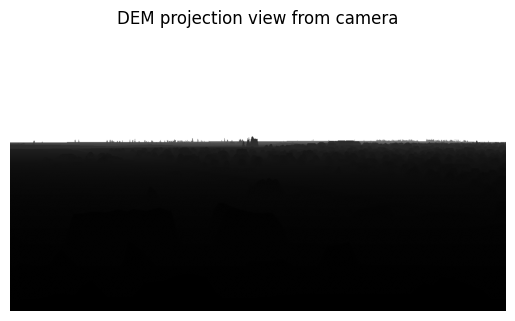

In [20]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# === Step 1: Build GeoRefCam ===
geocam = GeoRefCam(cam_model, dem)

# === Step 2: Camera position and direction ===
cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)

if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(np.array([geocam.camera_model.cam_loc[:3]]))[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]

print("📷 Camera XYZ:", cam_loc)
print("➡️ Direction Vector:", cam_dirvec)

# === Step 3: Compute vertical FOV ===
w, h = geocam.camera_model.image_res
fov_y_deg = 2 * np.degrees(
    np.arctan(np.tan(np.radians(geocam.camera_model.fov_x_deg / 2)) * (h / w))
)
print("📐 Vertical FOV:", fov_y_deg)

# === Step 4: Setup PyVista camera ===
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = fov_y_deg
pv_camera.clipping_range = (1, 10000)
pv_camera.up = (0, 0, 1)

# === Step 5: PyVista structured grid ===
z = geocam.dem.pcd[:, :, 2]
z[z < -1000] = np.nan
geocam.dem.pcd[:, :, 2] = z

grid = pv.StructuredGrid(*[geocam.dem.pcd[:, :, i] for i in range(3)])
grid["alt"] = z.ravel(order="F")

# === Step 6: Remove invalid (water) points
valid_grid = grid.threshold(value=-999, scalars="alt", invert=False)

print("🔧 Mesh points:", valid_grid.n_points)
print("🔧 Bounds:", valid_grid.bounds)

# === Step 7: Render
plotter = pv.Plotter(off_screen=True, window_size=(w, h))
plotter.camera = pv_camera
plotter.add_mesh(valid_grid, scalars="alt", lighting=False)
plotter.remove_scalar_bar()

# ✅ Must render manually before accessing depth
plotter.screenshot()

# Step 9: Capture depth map
dem_depth = -1 * plotter.get_image_depth()
dem_depth = np.nan_to_num(dem_depth, nan=1e6)

# === Step 8: Show image
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")
plt.axis('off')
plt.show()


In [21]:
np.save("dem_depth.npy", dem_depth)

In [22]:
dem_depth2  = np.load("dem_depth.npy" )

In [23]:
arr = dem_depth2.copy()
mask = arr==arr.max()

arr[mask] = 0
min_val = np.nanpercentile(arr[~mask], 0)
max_val = np.nanpercentile(arr[~mask], 95)
print(azimuth, min_val, max_val)
norm = (arr - min_val) / (max_val - min_val)
norm = np.clip(norm, 0, 1)

result = np.zeros_like(arr, dtype="float32")
result[~mask] = norm[~mask] * 255

42 75.40510559082031 925.9503784179688


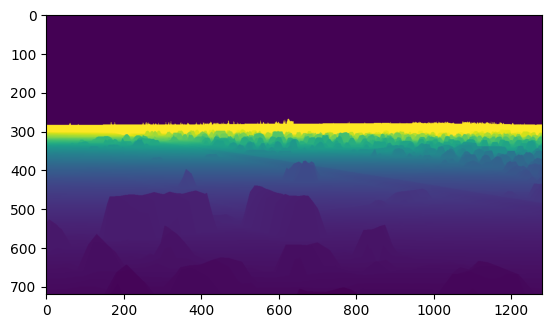

In [24]:
plt.imshow(result)

In [15]:
d==ddde

NameError: name 'd' is not defined

In [141]:
cv2.imwrite("res_proj.jpg", result*1)

True

In [18]:
def plot_camera_with_ray_on_map(cam_loc, dem_points, origin, target,
                                 azimuth_deg, fov_deg=54.2, view_distance=5000):
    import geopandas as gpd
    from shapely.geometry import Point, LineString, box
    import contextily as ctx
    import matplotlib.pyplot as plt
    from pyproj import Transformer

    # === Unpack camera location (x, y, z, crs) ===
    if isinstance(cam_loc, tuple) and len(cam_loc) == 4:
        cam_x, cam_y, cam_z, _ = cam_loc
    else:
        cam_x, cam_y, cam_z = cam_loc

    # === Bounds from DEM ===
    x_min, x_max = dem_points[:, :, 0].min(), dem_points[:, :, 0].max()
    y_min, y_max = dem_points[:, :, 1].min(), dem_points[:, :, 1].max()
    dem_geom = box(x_min, y_min, x_max, y_max)

    # === Create geometries ===
    cam_geom = Point(cam_x, cam_y)
    ray_line = LineString([(origin[0], origin[1]), (target[0], target[1])])
    target_point = Point(target[0], target[1])

    # === GeoDataFrames ===
    gdf_dem = gpd.GeoDataFrame({'geometry': [dem_geom]}, crs="EPSG:2154")
    gdf_cam = gpd.GeoDataFrame({'geometry': [cam_geom]}, crs="EPSG:2154")
    gdf_ray = gpd.GeoDataFrame({'geometry': [ray_line]}, crs="EPSG:2154")
    gdf_target = gpd.GeoDataFrame({'geometry': [target_point]}, crs="EPSG:2154")

    # === FOV cone ===
    half_fov = fov_deg / 2
    angles_deg = [azimuth_deg - half_fov, azimuth_deg + half_fov]
    angles_rad = np.radians(angles_deg)

    cone_pts = [
        cam_geom,
        Point(cam_x + view_distance * np.sin(angles_rad[0]),
              cam_y + view_distance * np.cos(angles_rad[0])),
        Point(cam_x + view_distance * np.sin(angles_rad[1]),
              cam_y + view_distance * np.cos(angles_rad[1]))
    ]
    fov_union = unary_union(cone_pts)
    gdf_fov = gpd.GeoSeries([fov_union.convex_hull], crs="EPSG:2154")

    # === Reproject all to Web Mercator ===
    gdf_dem_web = gdf_dem.to_crs(epsg=3857)
    gdf_cam_web = gdf_cam.to_crs(epsg=3857)
    gdf_ray_web = gdf_ray.to_crs(epsg=3857)
    gdf_target_web = gdf_target.to_crs(epsg=3857)
    gdf_fov_web = gdf_fov.to_crs(epsg=3857)

    # === Compute WGS84 coordinates of target ===
    tf = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
    lon, lat = tf.transform(target[0], target[1])
    label = f"Lat: {lat:.5f}\nLon: {lon:.5f}"
    print("🛰️ Target WGS84:", label.replace("\n", " | "))

    # === Plot ===
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_dem_web.boundary.plot(ax=ax, edgecolor='blue', linewidth=2, label='DEM extent')
    gdf_cam_web.plot(ax=ax, color='red', markersize=100, label='Camera location')
    gdf_ray_web.plot(ax=ax, color='black', linewidth=2, label='Projected pixel ray')
    gdf_target_web.plot(ax=ax, color='green', markersize=80, label='Ray target')
    gdf_fov_web.plot(ax=ax, color='orange', alpha=0.3, label='FOV cone')

    # Annotate
    x_target, y_target = gdf_target_web.geometry.iloc[0].x, gdf_target_web.geometry.iloc[0].y
    ax.annotate(label, (x_target, y_target), xytext=(5, 5), textcoords="offset points",
                fontsize=9, color='green',
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title("Camera with single pixel ray on real map")
    ax.set_axis_off()
    ax.legend()
    plt.tight_layout()
    plt.show()


In [19]:
# === Cast actual ray to get intersection ===
w, h = cam_model.image_res
center_pixel = np.array([[611, 391]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(center_pixel)


# Get real intersection using DSM mesh
rays_with_intersection = dem.cast_rays_seq(rays)
origin = rays_with_intersection[0, 0]  # camera origin
target = rays_with_intersection[0, 1]  # real intersection point (might be nan if missed)

# Optional check
if np.any(np.isnan(target)):
    print("⚠️ No intersection found in DSM for this pixel ray")
else:
    plot_camera_with_ray_on_map(
        cam_loc=cam_model.cam_loc,
        dem_points=dem.pcd,
        origin=origin,
        target=target,
        azimuth_deg=azimuth,
        fov_deg=fov_x
    )

Exception ignored on calling ctypes callback function: <function Index._create_idx_from_stream.<locals>.py_next_item at 0x56b5b0900>
Traceback (most recent call last):
  File "/Users/mateo/pyronear/vision/smoke-localization/.venv/lib/python3.11/site-packages/rtree/index.py", line 1390, in py_next_item
    def py_next_item(p_id, p_mins, p_maxs, p_dimension, p_data, p_length):

KeyboardInterrupt: 


ValueError: shape mismatch: value array of shape (0,) could not be broadcast to indexing result of shape (0,3)

In [ ]:
w, h = cam_model.image_res
center_pixel = np.array([[639, 359]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(center_pixel)

origin = cam_loc  # camera center in L93
direction = get_direction_vector(cam_model.azimuth_deg, cam_model.tilt_deg)
target, ind = dem.mesh.ray_trace(origin=origin, direction=direction, first_point=True)

if target is None:
    print("❌ Ray missed the DSM mesh")
else:
    print("✅ Ray hit DSM at:", target)


plot_camera_with_ray_on_map(
    cam_loc=cam_model.cam_loc,
    dem_points=dem.pcd,
    origin=origin,
    target=target,
    azimuth_deg=azimuth,
    fov_deg=fov_x
)


In [ ]:
from pyproj import Geod

g = Geod(ellps='WGS84')
lon1, lat1 = cam_model.tf_local_to_wgs84.transform(*origin[:2])
lon2, lat2 = cam_model.tf_local_to_wgs84.transform(*target[:2])
az, _, dist = g.inv(lon1, lat1, lon2, lat2)

print(f"📐 Computed azimuth (WGS84): {az:.2f}°")
print(f"📏 Distance to target: {dist:.2f} m")
print(f"📉 Origin Z: {origin[2]:.2f} | Target Z: {target[2]:.2f} | ∆Z = {origin[2] - target[2]:.2f}")


In [137]:
x_min, x_max = dem.pcd[:, :, 0].min(), dem.pcd[:, :, 0].max()
y_min, y_max = dem.pcd[:, :, 1].min(), dem.pcd[:, :, 1].max()

x_t, y_t = target[0], target[1]
if not (x_min <= x_t <= x_max and y_min <= y_t <= y_max):
    print("⚠️ Target lies OUTSIDE DEM extent — ray projection overshoots!")


In [ ]:
dist = np.linalg.norm(target[:2] - origin[:2])
print(f"📏 Horizontal ground distance of ray: {dist/1000:.2f} km")


In [ ]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt

# === Step 1: Compute camera location and direction ===
geocam = GeoRefCam(cam_model, dem)

cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)
cam_loc = geocam.project_points_from_cam_to_dem_crs(
    np.array([geocam.camera_model.cam_loc[:3]])
)[0] if geocam.camera_model.cam_loc[3] != geocam.dem.crs else geocam.camera_model.cam_loc[:3]

print("📷 Camera location (x, y, z):", cam_loc)
print("➡️  Direction vector:", cam_dirvec)

# === Step 2: Compute vertical field of view ===
w, h = geocam.camera_model.image_res
fov_y_deg = 2 * np.degrees(np.arctan(np.tan(np.radians(geocam.camera_model.fov_x_deg / 2)) * (h / w)))
print("📐 Computed vertical FOV (deg):", fov_y_deg)

# === Step 3: Setup PyVista Camera ===
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = fov_y_deg
pv_camera.clipping_range = (30, 3000)
pv_camera.up = (0, 0, 1)

# === Step 4: Flip Y-axis and clean DEM ===
pcd = geocam.dem.pcd.copy()
z = pcd[:, :, 2]
z[z < -1000] = np.nan
z[np.isnan(z)] = np.nanmedian(z)
pcd[:, :, 2] = z

# Flip Y-axis to correct orientation for PyVista
pcd_flipped = pcd[::-1, :, :]
print("✅ Flipped Y-axis for correct mesh orientation")

# === Step 5: Create PyVista mesh ===
plot_pv_meshgrid = pv.StructuredGrid(
    pcd_flipped[:, :, 0],
    pcd_flipped[:, :, 1],
    pcd_flipped[:, :, 2]
)
plot_pv_meshgrid["alt"] = pcd_flipped[:, :, 2].ravel(order="F")

# === Step 6: Create plotter and add terrain ===
plotter = pv.Plotter(off_screen=True, window_size=(w, h))
plotter.camera = pv_camera
plotter.add_mesh(plot_pv_meshgrid, scalars="alt", cmap="terrain", lighting=False)
plotter.remove_scalar_bar()

# === Step 7: Draw center pixel ray ===
center_px = np.array([[w / 2, h / 2]], dtype=float)
ray = geocam.camera_model.project_pixel_points_to_world_rays(center_px)
ray_origin = ray[0, :, 0]
ray_target = ray[0, :, 1]
print("🎯 Center ray origin:", ray_origin)
print("🎯 Center ray target:", ray_target)

plotter.add_lines(np.array([ray_origin, ray_target]), color='green', width=3)

# === Step 8: Draw direction arrow from camera ===
plotter.add_arrows(np.array(cam_loc).reshape(1, 3), np.array(cam_dirvec).reshape(1, 3) * 500, color='red')

# === Step 9: Add sampled DEM points as debug markers ===
pcd_flat = pcd_flipped.reshape(-1, 3)
valid = ~np.isnan(pcd_flat[:, 2])
sample_indices = np.random.choice(np.where(valid)[0], size=10, replace=False)
sample_points = pcd_flat[sample_indices]

print("🔵 Sampled DEM points:")
for pt in sample_points:
    print("   ", pt)
    sphere = pv.Sphere(radius=30, center=pt)
    plotter.add_mesh(sphere, color='blue')

# === Step 10: Render and extract depth map ===
plotter.screenshot()
depth = plotter.get_image_depth()
dem_depth = np.nan_to_num(depth, nan=1e6)

# === Step 11: Display final result ===
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")
plt.axis('off')
plt.show()


In [ ]:
cam_loc

In [174]:
# import numpy as np
# import pyvista as pv
# import matplotlib.pyplot as plt

# # === Reuse camera + DEM setup ===
# geocam = GeoRefCam(cam_model, dem)
# cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)
# cam_loc = geocam.project_points_from_cam_to_dem_crs(
#     np.array([geocam.camera_model.cam_loc[:3]])
# )[0] if geocam.camera_model.cam_loc[3] != geocam.dem.crs else geocam.camera_model.cam_loc[:3]

# print("📷 Camera location (x, y, z):", cam_loc)
# print("➡️  Direction vector:", cam_dirvec)

# w, h = geocam.camera_model.image_res
# fov_y_deg = 2 * np.degrees(np.arctan(np.tan(np.radians(geocam.camera_model.fov_x_deg / 2)) * (h / w)))
# print("📐 Computed vertical FOV (deg):", fov_y_deg)

# # === Create camera ===
# pv_camera = pv.Camera()
# pv_camera.position = cam_loc
# pv_camera.focal_point = cam_loc + cam_dirvec
# pv_camera.view_angle = fov_y_deg
# pv_camera.clipping_range = (30, 5000)
# pv_camera.up = (0, 0, 1)

# # === Clean + flip DEM ===
# pcd = geocam.dem.pcd.copy()
# z = pcd[:, :, 2]
# z[z < -1000] = np.nan
# z[np.isnan(z)] = np.nanmedian(z)
# pcd[:, :, 2] = z
# pcd_flipped = pcd[::-1, :, :]

# # === Build surface mesh ===
# grid = pv.StructuredGrid(pcd_flipped[:, :, 0], pcd_flipped[:, :, 1], pcd_flipped[:, :, 2])
# grid["alt"] = pcd_flipped[:, :, 2].ravel(order="F")
# surf = grid.extract_surface()

# print(f"🔧 Surface mesh has {surf.n_points} points, {surf.n_cells} cells")

# # === Plotter setup ===
# plotter = pv.Plotter(off_screen=True, window_size=(w, h))
# plotter.camera = pv_camera
# plotter.add_mesh(surf, scalars="alt", cmap="terrain", lighting=False)
# plotter.add_arrows(np.array(cam_loc).reshape(1, 3), np.array(cam_dirvec).reshape(1, 3) * 500, color='red')
# plotter.remove_scalar_bar()

# # === MUST CALL show() before get_image_depth ===
# plotter.show(auto_close=False)  # ← mandatory to initialize rendering context

# # === Extract and normalize depth ===
# depth = plotter.get_image_depth()
# depth = np.nan_to_num(depth, nan=np.max(depth))
# depth_norm = (depth - depth.min()) / (depth.max() - depth.min())

# # === Display ===
# plt.imshow(depth_norm, cmap='gray')
# plt.title("DEM projection view from camera (normalized)")
# plt.axis('off')
# plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Flatten DEM points
pcd = geocam.dem.pcd.reshape(-1, 3)  # Shape (N, 3)
valid_mask = ~np.isnan(pcd[:, 2]) & (pcd[:, 2] > -1000)
pcd_valid = pcd[valid_mask]

# Step 2: Project 3D points to image plane
# Convert to WGS84 if needed
if geocam.dem.crs != CRS.from_epsg(4326):
    x, y, z = pcd_valid[:, 0], pcd_valid[:, 1], pcd_valid[:, 2]
    lon, lat = geocam.camera_model.tf_local_to_wgs84.transform(x, y)
    pts_wgs84 = np.column_stack([lat, lon, z])
else:
    pts_wgs84 = pcd_valid

# Use cameratransform to project to pixels
px = geocam.camera_model.cam_model.imageFromGPS(pts_wgs84)

# Step 3: Filter points inside image
w, h = geocam.camera_model.image_res
mask = (
    (px[:, 0] >= 0) & (px[:, 0] < w) &
    (px[:, 1] >= 0) & (px[:, 1] < h)
)
px_in_img = px[mask]
z_in_img = pcd_valid[mask, 2]

# Step 4: Create empty image and fill with depth
img = np.full((h, w), np.nan)
for (x, y), z_val in zip(px_in_img, z_in_img):
    xi, yi = int(x), int(y)
    img[yi, xi] = z_val  # Assign depth (or intensity)

# Step 5: Display projected DEM as seen from camera
img_display = np.nan_to_num(img, nan=np.nanmin(z_in_img))
plt.imshow(img_display, cmap='terrain')
plt.title("DEM projection from camera using CTCameraModel")
plt.axis('off')
plt.show()


In [ ]:
import numpy as np

# Simulate a camera model and DEM surface for ray projection demo

# Dummy camera model class with required method
class DummyCameraModel:
    def __init__(self, image_res, azimuth_deg, tilt_deg):
        self.image_res = image_res
        self.azimuth_deg = azimuth_deg
        self.tilt_deg = tilt_deg

    def project_pixel_points_to_world_rays(self, pixels):
        # Simplified: output origin + a direction vector scaled arbitrarily
        origin = np.array([100.0, 100.0, 100.0])
        rays = []
        for px in pixels:
            x_angle = (px[0] - self.image_res[0] / 2) * (60.0 / self.image_res[0])
            y_angle = (px[1] - self.image_res[1] / 2) * (45.0 / self.image_res[1])
            direction = np.array([np.sin(np.radians(x_angle)),
                                  np.cos(np.radians(x_angle)),
                                  -np.sin(np.radians(y_angle))])
            endpoint = origin + direction * 100
            rays.append((origin, endpoint))
        return rays

# Parameters
img_width, img_height = 64, 36  # small for demo
cam_model = DummyCameraModel((img_width, img_height), azimuth_deg=310, tilt_deg=-4)

# Create a mock DEM heightmap (flat with bumps)
dem_resolution = (img_height, img_width)
dem_surface = np.ones(dem_resolution) * 90
dem_surface[15:20, 30:35] += 10  # bump in center

# Cast rays and get depth intersection with simplified DEM
depth_map = np.full(dem_resolution, np.nan)

for y in range(img_height):
    for x in range(img_width):
        ray = cam_model.project_pixel_points_to_world_rays(np.array([[x, y]]))[0]
        origin, endpoint = ray

        # Simplified intersection: we assume z = DEM[y, x] at each pixel
        dem_z = dem_surface[y, x]
        ray_dir = endpoint - origin
        if ray_dir[2] == 0:
            continue  # parallel ray

        t = (dem_z - origin[2]) / ray_dir[2]
        if t < 0:
            continue  # behind camera

        intersection = origin + t * ray_dir
        distance = np.linalg.norm(intersection - origin)
        depth_map[y, x] = distance

import matplotlib.pyplot as plt
plt.imshow(depth_map, cmap='gray')
plt.title("Depth map via ray/DEM Z intersection")
plt.axis('off')
plt.show()


In [169]:
##plot_pv_meshgrid.plot(scalars="alt", cmap="terrain")


In [ ]:
print("Mesh has NaNs:", np.isnan(pcd_flipped).any())
print("StructuredGrid valid:", plot_pv_meshgrid.n_cells > 0 and plot_pv_meshgrid.n_points > 0)


In [ ]:
# Flatten DEM point cloud and find closest point to camera XY
pcd_flat = geocam.dem.pcd.reshape(-1, 3)
dists = np.linalg.norm(pcd_flat[:, :2] - cam_loc[:2], axis=1)
closest_idx = np.argmin(dists)
nearest_pt = pcd_flat[closest_idx]

print("📍 Closest DEM point to camera:", nearest_pt)
print("📏 Camera Z:", cam_loc[2])
print("📏 DEM Z at that XY:", nearest_pt[2])
print("📐 Z diff (cam - dem):", cam_loc[2] - nearest_pt[2])


In [ ]:
print("DEM Z min:", z.min())
print("DEM Z max:", z.max())
print("Mesh shape:", geocam.dem.pcd.shape)
print("Mesh spacing X:", np.mean(np.diff(geocam.dem.pcd[0,:,0])))
print("Mesh spacing Y:", np.mean(np.diff(geocam.dem.pcd[:,0,1])))


In [ ]:
cam_dirvec

In [ ]:


rgb, depth = render_dem_from_camera(geocam)

# Save RGB image and depth
from PIL import Image
Image.fromarray(rgb).save("rendered_image.png")

depth_image = np.nan_to_num(-1 * depth, nan=1e6)  # Convert to positive and replace nan
cv2.imwrite("rendered_depth.png", (depth_image / depth_image.max() * 255).astype(np.uint8))


In [ ]:
plt.imshow(rgb)

In [101]:
geocam = GeoRefCam(cam_model, dem)
cam_dirvec = get_direction_vector(geocam.camera_model.azimuth_deg, geocam.camera_model.tilt_deg)

# Reproject camera location if needed
if geocam.camera_model.cam_loc[3] != geocam.dem.crs:
    cam_loc = geocam.project_points_from_cam_to_dem_crs(
        np.array([geocam.camera_model.cam_loc[:3]])
    )[0]
else:
    cam_loc = geocam.camera_model.cam_loc[:3]

In [ ]:
# Setup PyVista camera
pv_camera = pv.Camera()
pv_camera.position = cam_loc
pv_camera.focal_point = cam_loc + cam_dirvec
pv_camera.view_angle = geocam.camera_model.fov_x_deg
pv_camera.clipping_range = (30, 1e5)
pv_camera.up = (0, 0, 1)

# Create plot
plotter = pv.Plotter(off_screen=True, window_size=img_size)
plotter.camera = pv_camera

plot_pv_meshgrid = pv.StructuredGrid(*[geocam.dem.pcd[:, :, i] for i in range(3)])
plot_pv_meshgrid["alt"] = geocam.dem.pcd[:, :, 2].ravel(order="F")
plotter.add_mesh(plot_pv_meshgrid, lighting=False)
plotter.remove_scalar_bar()

plotter.screenshot()
dem_depth = -1 * plotter.get_image_depth()



# === Display Result ===
plt.imshow(dem_depth, cmap='gray')
plt.title("DEM projection view from camera")

plt.show()


In [43]:
def plot_camera_with_ray_on_map(cam_loc, dem_points, origin, target,
                                 azimuth_deg, fov_deg=54.2, view_distance=3000):
    import geopandas as gpd
    from shapely.geometry import Point, LineString, box
    import contextily as ctx
    import matplotlib.pyplot as plt
    from pyproj import Transformer

    # Bounds
    x_min, x_max = dem_points[:, :, 0].min(), dem_points[:, :, 0].max()
    y_min, y_max = dem_points[:, :, 1].min(), dem_points[:, :, 1].max()
    cam_x, cam_y, _, _ = cam_loc

    # Build GeoDataFrames in LAMB93
    dem_geom = box(x_min, y_min, x_max, y_max)
    cam_geom = Point(cam_x, cam_y)

    gdf_dem = gpd.GeoDataFrame({'geometry': [dem_geom]}, crs="EPSG:2154")
    gdf_cam = gpd.GeoDataFrame({'geometry': [cam_geom]}, crs="EPSG:2154")

    # FOV cone (optional)
    half_fov = fov_deg / 2
    angles_deg = [azimuth_deg - half_fov, azimuth_deg + half_fov]
    angles_rad = [np.deg2rad(a) for a in angles_deg]

    cone_pts = [
        cam_geom,
        Point(cam_x + view_distance * np.sin(angles_rad[0]),
              cam_y + view_distance * np.cos(angles_rad[0])),
        Point(cam_x + view_distance * np.sin(angles_rad[1]),
              cam_y + view_distance * np.cos(angles_rad[1]))
    ]
  
      fov_union = unary_union(cone_pts)
      gdf_fov = gpd.GeoSeries([fov_union.convex_hull], crs="EPSG:2154")

    # Ray line (camera to projected pixel)
    ray_line = LineString([(origin[0], origin[1]), (target[0], target[1])])
    gdf_ray = gpd.GeoDataFrame({'geometry': [ray_line]}, crs="EPSG:2154")
    target_point = Point(target[0], target[1])
    gdf_target = gpd.GeoDataFrame({'geometry': [target_point]}, crs="EPSG:2154")

    # Convert target to lat/lon
    tf = Transformer.from_crs("EPSG:2154", "EPSG:4326", always_xy=True)
    lon, lat = tf.transform(target[0], target[1])
    label = f"Lat: {lat:.5f}\nLon: {lon:.5f}"
    print("Target WGS84:", label.replace("\n", " | "))

    # Reproject all to Web Mercator
    gdf_dem_web = gdf_dem.to_crs(epsg=3857)
    gdf_cam_web = gdf_cam.to_crs(epsg=3857)
    gdf_fov_web = gdf_fov.to_crs(epsg=3857)
    gdf_ray_web = gdf_ray.to_crs(epsg=3857)
    gdf_target_web = gdf_target.to_crs(epsg=3857)
    x_target, y_target = gdf_target_web.geometry.iloc[0].x, gdf_target_web.geometry.iloc[0].y

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_dem_web.boundary.plot(ax=ax, edgecolor='blue', linewidth=2, label='DEM extent')
    gdf_cam_web.plot(ax=ax, color='red', markersize=100, label='Camera location')
    gdf_fov_web.plot(ax=ax, color='orange', alpha=0.3, label='FOV cone')
    gdf_ray_web.plot(ax=ax, color='black', linewidth=2, label='Projected pixel ray')
    gdf_target_web.plot(ax=ax, color='green', markersize=80, label='Ray target')

    # Annotate lat/lon
    ax.annotate(label, (x_target, y_target), xytext=(5, 5), textcoords="offset points",
                fontsize=9, color='green', bbox=dict(facecolor='white', alpha=0.8, boxstyle='round'))

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
    ax.set_title("Camera with single pixel ray on real map")
    ax.set_axis_off()
    ax.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
w, h = cam_model.image_res
center_pixel = np.array([[w / 2, h/2 ]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(center_pixel)

origin = rays[0, :, 0]
target = rays[0, :, 1]

plot_camera_with_ray_on_map(
    cam_loc=cam_model.cam_loc,
    dem_points=dem.pcd,               # Your point cloud from RasterioDEM
    origin=origin,
    target=target,
    azimuth_deg=azimuth,
    fov_deg=fov_x                     # Optional: for cone display
)


In [ ]:
hfov = 54.0              # the horizontal FOV you want
w, h = img_size          # width, height of your render window
vfov = 2 * np.degrees(   
    np.arctan(np.tan(np.radians(hfov/2)) * (h / w))
)

# Step 6: Setup PyVista camera
pv_camera = pv.Camera()
pv_camera.position       = origin
pv_camera.focal_point    = target
pv_camera.vfov     = cam_model.fov_y_deg   # VFOV vertical
pv_camera.clipping_range = (30, 1e5)
pv_camera.up             = (0, 0, 1)

# Step 7: Setup the PyVista plotter
plotter = pv.Plotter(off_screen=True, window_size=img_size)
plotter.camera = pv_camera

# Step 8: Prepare and render the mesh
if np.isnan(dem_points).any():
    dem_points = np.nan_to_num(dem_points, nan=1e6)

grid = pv.StructuredGrid(*[dem_points[:, :, i] for i in range(3)])
grid["alt"] = dem_points[:, :, 2].ravel(order="F")

plotter.add_mesh(grid, lighting=False)
plotter.remove_scalar_bar()
plotter.screenshot()

# Step 9: Capture depth map
dem_depth = -1 * plotter.get_image_depth()
dem_depth = np.nan_to_num(dem_depth, nan=1e6)

In [ ]:
# === Cast actual ray to get intersection ===
w, h = cam_model.image_res
center_pixel = np.array([[w / 2, h / 2]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(center_pixel)

# Get real intersection using DSM mesh
rays_with_intersection = dem.cast_rays_seq(rays)
origin = rays_with_intersection[0, 0]  # camera origin
target = rays_with_intersection[0, 1]  # real intersection point (might be nan if missed)

# Optional check
if np.any(np.isnan(target)):
    print("⚠️ No intersection found in DSM for this pixel ray")
else:
    plot_camera_with_ray_on_map(
        cam_loc=cam_model.cam_loc,
        dem_points=dem.pcd,
        origin=origin,
        target=target,
        azimuth_deg=azimuth,
        fov_deg=fov_x
    )


In [ ]:
print("[DEBUG] azimuth_deg input:", azimuth)
print("[DEBUG] heading_for_ct (yaw):", (90 - cam.azimuth_deg) % 360)


In [9]:
azimuth = 310
heading_for_ct = (90 - azimuth) % 360  # = (90 - 310) % 360 = 140


In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import geopandas as gpd
import contextily as ctx
from shapely.geometry import Point, box
import numpy as np

def plot_camera_with_basemap(cam_loc, dem_points, azimuth_deg, fov_deg=54.2, view_distance=5000):
    x_min, x_max = dem_points[:, :, 0].min(), dem_points[:, :, 0].max()
    y_min, y_max = dem_points[:, :, 1].min(), dem_points[:, :, 1].max()
    cam_x, cam_y, _ = cam_loc

    # Build GeoDataFrames in LAMB93
    dem_geom = box(x_min, y_min, x_max, y_max)
    cam_geom = Point(cam_x, cam_y)

    gdf_dem = gpd.GeoDataFrame({'geometry': [dem_geom]}, crs="EPSG:2154")
    gdf_cam = gpd.GeoDataFrame({'geometry': [cam_geom]}, crs="EPSG:2154")

    # FOV cone endpoints in LAMB93
    half_fov = fov_deg / 2
    angles_deg = [azimuth_deg - half_fov, azimuth_deg + half_fov]
    angles_rad = [np.deg2rad(a) for a in angles_deg]

    # Create two edge points
    cone_pts = [
        cam_geom,  # origin
        Point(cam_x + view_distance * np.sin(angles_rad[0]),
              cam_y + view_distance * np.cos(angles_rad[0])),
        Point(cam_x + view_distance * np.sin(angles_rad[1]),
              cam_y + view_distance * np.cos(angles_rad[1]))
    ]
    gdf_fov = gpd.GeoSeries([gpd.GeoSeries(cone_pts).unary_union.convex_hull], crs="EPSG:2154")

    # Reproject all to Web Mercator
    gdf_dem_web = gdf_dem.to_crs(epsg=3857)
    gdf_cam_web = gdf_cam.to_crs(epsg=3857)
    gdf_fov_web = gdf_fov.to_crs(epsg=3857)

    # Plot
    fig, ax = plt.subplots(figsize=(10, 10))
    gdf_dem_web.boundary.plot(ax=ax, edgecolor='blue', linewidth=2, label='DEM extent')
    gdf_cam_web.plot(ax=ax, color='red', markersize=100, label='Camera location')
    gdf_fov_web.plot(ax=ax, color='orange', alpha=0.4, label='Camera FOV')

    ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

    ax.set_title("Camera & DEM with FOV on Real Map")
    ax.set_axis_off()
    ax.legend()
    plt.tight_layout()
    plt.show()


In [28]:
#plot_camera_with_basemap(cam_loc, dem_points, azimuth, fov_deg=54.2, view_distance=3000)


In [29]:
hfov = 54.0              # the horizontal FOV you want
w, h = img_size          # width, height of your render window
vfov = 2 * np.degrees(   
    np.arctan(np.tan(np.radians(hfov/2)) * (h / w))
)

# Step 6: Setup PyVista camera
pv_camera = pv.Camera()
pv_camera.position       = origin
pv_camera.focal_point    = target
pv_camera.vfov     = cam_model.fov_y_deg   # VFOV vertical
pv_camera.clipping_range = (30, 1e5)
pv_camera.up             = (0, 0, 1)

# Step 7: Setup the PyVista plotter
plotter = pv.Plotter(off_screen=True, window_size=img_size)
plotter.camera = pv_camera

# Step 8: Prepare and render the mesh
if np.isnan(dem_points).any():
    dem_points = np.nan_to_num(dem_points, nan=1e6)

grid = pv.StructuredGrid(*[dem_points[:, :, i] for i in range(3)])
grid["alt"] = dem_points[:, :, 2].ravel(order="F")

plotter.add_mesh(grid, lighting=False)
plotter.remove_scalar_bar()
plotter.screenshot()

# Step 9: Capture depth map
dem_depth = -1 * plotter.get_image_depth()
dem_depth = np.nan_to_num(dem_depth, nan=1e6)

In [ ]:
pv_camera.view_angle

In [ ]:
plt.imshow(dem_depth)

In [ ]:
dem_depth.max(), dem_depth.min()

In [ ]:
arr = dem_depth.copy()
mask = arr==arr.max()

arr[mask] = 0

min_val = np.nanpercentile(arr[~mask], 5)
max_val = np.nanpercentile(arr[~mask], 95)
print( min_val, max_val)
norm = (arr - min_val) / (max_val - min_val)
norm = np.clip(norm, 0, 1)

result = np.zeros_like(arr, dtype="float32")
result[~mask] = norm[~mask] * 255

In [ ]:
plt.imshow(result)

In [ ]:
cv2.imwrite("res.jpg", result)

In [ ]:
import numpy as np

w, h = cam_model.image_res

# build a single “centre-pixel” ray
centre_px = np.array([[w/2, h/2]], dtype=float)
rays = cam_model.project_pixel_points_to_world_rays(centre_px)

origin   = rays[0, :, 0]   # (x, y, z) of camera
endpoint = rays[0, :, 1]   # (x, y, z) of the 100 km point

dx, dy = endpoint[0] - origin[0], endpoint[1] - origin[1]

# compute its bearing in the horizontal plane
centre_az = (np.degrees(np.arctan2(dx, dy)) + 360) % 360
print("CT thinks centre-pixel is pointing at azimuth:", centre_az)


In [ ]:
azimuth_deg = 336
heading_for_ct = (90 - azimuth_deg) % 360
print("heading_for_ct =", heading_for_ct)  # Expecting 114

# back-project to heading_for_ct
computed_heading_from_dxdy = (90 - centre_az) % 360
print("Expected heading_for_ct =", heading_for_ct)
print("Computed heading_from_ray =", (90 - centre_az) % 360)


In [168]:
# 1) compute the exact world‐space target of the centre pixel
centre = np.array([[w/2, h/2]])
rays   = cam_model.project_pixel_points_to_world_rays(centre)
origin = rays[0,:,0]
target = rays[0,:,1]

# 2) drop *that* into your PyVista camera
pv_camera.position    = origin
pv_camera.focal_point = target


In [ ]:
origin, target

In [170]:
pv_camera = pv.Camera()
pv_camera.position       = origin
pv_camera.focal_point    = target
pv_camera.view_angle     = cam_model.azimuth_deg   # vertical FOV
pv_camera.clipping_range = (30, 1e5)
pv_camera.up             = (0, 0, 1)


In [171]:
plotter = pv.Plotter(off_screen=True, window_size=img_size)
plotter.camera = pv_camera


In [172]:

# Step 8: Prepare and render the mesh
if np.isnan(dem_points).any():
    dem_points = np.nan_to_num(dem_points, nan=1e6)

grid = pv.StructuredGrid(*[dem_points[:, :, i] for i in range(3)])
grid["alt"] = dem_points[:, :, 2].ravel(order="F")

plotter.add_mesh(grid, lighting=False)
plotter.remove_scalar_bar()
plotter.screenshot()

# Step 9: Capture depth map
dem_depth = -1 * plotter.get_image_depth()
dem_depth = np.nan_to_num(dem_depth, nan=1e6)

In [ ]:
# test_cam = CTCameraModel(
#     image_res=(1920, 1080),
#     fov_x_deg=60,
#     fov_y_deg=45,
#     azimuth_deg=24,
#     tilt_deg=0,
#     roll_deg=0,
#     lat=0,
#     lon=0,
#     elevation=0,
#     crs="EPSG:4326"
# )

w, h = test_cam.image_res
centre_px = np.array([[w / 2, h / 2]], dtype=float)
rays = test_cam.project_pixel_points_to_world_rays(centre_px)

origin = rays[0, :, 0]
target = rays[0, :, 1]
dx, dy = target[0] - origin[0], target[1] - origin[1]
azimuth = (np.degrees(np.arctan2(dx, dy)) + 360) % 360

print("Expected azimuth: 336°")
print("Computed center ray azimuth:", azimuth)


In [ ]:
import cameratransform as ct
import numpy as np

image_res = (1920, 1080)
fov_x, fov_y = 60, 45
azimuth_deg = 336
heading_for_ct = (90 - azimuth_deg) % 360

cam = ct.Camera(
    ct.RectilinearProjection(
        image=image_res,
        view_x_deg=fov_x,
        azimuth_deg=fov_y
    ),
    ct.SpatialOrientationYawPitchRoll(
        yaw_deg=heading_for_ct,   # 114 expected
        pitch_deg=0,
        roll_deg=0,
        elevation_m=0
    )
)
cam.setGPSpos(lat=0, lon=0)

centre_px = np.array([[image_res[0] / 2, image_res[1] / 2]])
rays_wgs = cam.gpsFromImage(centre_px)
origin = np.array([0, 0, 0])  # cam at (0, 0, 0)
target = rays_wgs[0]          # (lat, lon, alt)

# convert to x/y assuming small distance (for debug)
dy = target[0] - 0  # lat diff
dx = target[1] - 0  # lon diff
az = (np.degrees(np.arctan2(dx, dy)) + 360) % 360

print("Heading for CT:", heading_for_ct)
print("Computed ray azimuth:", az)
print("Target WGS84:", target)


In [ ]:
import cameratransform as ct
import numpy as np

image_res = (1920, 1080)
fov_x, fov_y = 60, 45
azimuth_deg = 336
heading_for_ct = (90 - azimuth_deg) % 360

cam = ct.Camera(
    ct.RectilinearProjection(
        image=image_res,
        view_x_deg=fov_x,
        azimuth_deg=fov_y
    ),
    ct.SpatialOrientationYawPitchRoll(
        yaw_deg=heading_for_ct,   # 114 expected
        pitch_deg=-5,             # slight downward tilt
        roll_deg=0,
        elevation_m=10            # 10m above ground
    )
)
cam.setGPSpos(lat=0, lon=0)

centre_px = np.array([[image_res[0] / 2, image_res[1] / 2]])
rays_wgs = cam.gpsFromImage(centre_px)
origin = np.array([0, 0, 10])
target = rays_wgs[0]

dy = target[0] - 0
dx = target[1] - 0
az = (np.degrees(np.arctan2(dx, dy)) + 360) % 360

print("Heading for CT:", heading_for_ct)
print("Computed ray azimuth:", az)
print("Target WGS84:", target)
